# 🧠 NeuroEEGNet — Notebook 2: Architecture & Training
## *EEGNet + Transformer with Self-Supervised Learning for Alzheimer's Detection*

---

| Component | Details |
|-----------|---------|
| EEGNet Block | Temporal Conv → Depthwise → Separable Conv (128-dim) |
| Transformer Encoder | 6× Multi-Head Attention, 8 heads, d=256 |
| SSL Pretraining | MAE (Masked Autoencoder) + SimCLR (Contrastive) |
| Fine-tuning | Alzheimer's Disease (3-class: HC / FTD / AD) |
| Dataset | OpenNeuro ds004504 — 88 subjects, 256 Hz |
| Hardware | NVIDIA RTX 4050 Laptop GPU (5GB VRAM) |

---



## 1. Setup & GPU Verification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import warnings, os, time
warnings.filterwarnings('ignore')

# ── GPU Configuration ──────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   CUDA: {torch.version.cuda}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True  # TF32 for RTX 30/40 series speedup

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'text.color': 'white', 'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'axes.edgecolor': '#30363d', 'grid.color': '#21262d', 'grid.alpha': 0.4,
})


## 2. Data Loading

In [ ]:
# ── Load preprocessed epochs from Notebook 1 ──────────────────────────────────
import numpy as np, torch
from torch.utils.data import TensorDataset, DataLoader, random_split

ad_X = np.load('data/processed/ad_epochs.npy')
ad_y = np.load('data/processed/ad_labels.npy')

print(f"📂 Loaded ds004504 epochs:")
print(f"   ad_epochs : {ad_X.shape}  ({ad_X.nbytes/1e6:.1f} MB)")
print(f"   ad_labels : {ad_y.shape}")
print(f"   HC  epochs : {(ad_y==0).sum()}")
print(f"   FTD epochs : {(ad_y==1).sum()}")
print(f"   AD  epochs : {(ad_y==2).sum()}")

# Build PyTorch dataset
ad_ds = TensorDataset(torch.FloatTensor(ad_X), torch.LongTensor(ad_y))
print(f"\n✅ Dataset ready — {len(ad_ds):,} total samples")


## 3. NeuroEEGNet Architecture

In [ ]:
class EEGNetBlock(nn.Module):
    """
    EEGNet-inspired feature extractor.
    Input: (B, C, T) — batch, channels, time
    Output: (B, 128, T//8)
    Reference: Lawhern et al. (2018), J. Neural Eng.
    """
    def __init__(self, n_channels=19, n_filters=16, d_model=128):
        super().__init__()
        D = 2  # depth multiplier for depthwise conv
        
        # Temporal convolution: learn frequency-domain features
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, n_filters, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(n_filters),
        )
        
        # Depthwise convolution: learn spatial (channel) filters
        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(n_filters, n_filters*D, (n_channels, 1), groups=n_filters, bias=False),
            nn.BatchNorm2d(n_filters*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.25),
        )
        
        # Separable convolution: combine spatial-temporal features
        self.separable_conv = nn.Sequential(
            nn.Conv2d(n_filters*D, n_filters*D, (1, 16), padding=(0,8), groups=n_filters*D, bias=False),
            nn.Conv2d(n_filters*D, d_model, 1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.ELU(),
            nn.AvgPool2d((1, 2)),
            nn.Dropout(0.25),
        )
    
    def forward(self, x):
        # x: (B, C, T)
        x = x.unsqueeze(1)               # (B, 1, C, T)
        x = self.temporal_conv(x)         # (B, 16, C, T)
        x = self.depthwise_conv(x)        # (B, 32, 1, T//4)
        x = x.squeeze(2).unsqueeze(1)     # treat as 1D: (B, 1, 32, T//4)
        x = x.squeeze(1)                  # (B, 32, T//4) wait, need reshape
        # Actually just directly process
        return x


class EEGNetBlock(nn.Module):
    """Corrected EEGNet block."""
    def __init__(self, n_channels=19, n_filters=16, d_model=128, dropout=0.25):
        super().__init__()
        D = 2
        
        self.block1 = nn.Sequential(
            nn.Conv1d(n_channels, n_filters, 64, padding=32, bias=False),
            nn.BatchNorm1d(n_filters),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(n_filters, n_filters*D, 1, groups=n_filters, bias=False),
            nn.BatchNorm1d(n_filters*D),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(n_filters*D, n_filters*D, 16, padding=8, groups=n_filters*D, bias=False),
            nn.Conv1d(n_filters*D, d_model, 1, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ELU(),
            nn.AvgPool1d(2),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        # x: (B, C, T)
        x = self.block1(x)   # (B, n_filters, T)
        x = self.block2(x)   # (B, n_filters*D, T//4)
        x = self.block3(x)   # (B, d_model, T//8)
        return x              # (B, 128, T//8)


class NeuroEEGNet(nn.Module):
    """
    Full NeuroEEGNet: EEGNet + Transformer Encoder + Task Heads.
    
    Architecture:
        Input (B, 19, T)
         → EEGNetBlock → (B, 128, T//8)
         → Transpose → (B, T//8, 128)
         → Positional Encoding
         → 6× TransformerEncoderLayer (8 heads, d=256)
         → CLS token → (B, 256)
         → Task Head
    """
    def __init__(self, n_channels=19, seq_len=1000, d_model=256,
                 n_heads=8, n_layers=6, n_eegnet_filters=16,
                 eegnet_dim=128, dropout=0.1):
        super().__init__()
        self.eegnet = EEGNetBlock(n_channels, n_eegnet_filters, eegnet_dim, dropout=0.25)
        
        # Projection to transformer d_model
        self.proj = nn.Linear(eegnet_dim, d_model)
        
        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
        # Positional encoding (learnable)
        eeg_out_len = seq_len // 8 + 1  # +1 for CLS
        self.pos_embedding = nn.Parameter(torch.zeros(1, eeg_out_len + 1, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        
        # Task head — Alzheimer's Disease (HC / FTD / AD)
        self.ad_head = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, 3)
        )
        
        # MAE decoder (for self-supervised pretraining)
        self.mae_decoder = nn.Sequential(
            nn.Linear(d_model, d_model*2), nn.GELU(),
            nn.Linear(d_model*2, eegnet_dim)
        )
    
    def encode(self, x):
        """Forward through EEGNet + Transformer, return CLS embedding."""
        feats = self.eegnet(x)          # (B, 128, T//8)
        feats = feats.permute(0, 2, 1)  # (B, T//8, 128)
        feats = self.proj(feats)         # (B, T//8, 256)
        
        B, S, D = feats.shape
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, feats], dim=1)  # (B, S+1, D)
        
        # Positional embedding (handle variable sequence lengths)
        if tokens.shape[1] <= self.pos_embedding.shape[1]:
            tokens = tokens + self.pos_embedding[:, :tokens.shape[1], :]
        
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)
        return tokens[:, 0]  # CLS token: (B, 256)
    
    def forward(self, x, task='ad'):
        cls = self.encode(x)
        if task == 'ad':
            return self.ad_head(cls)
        else:
            return cls  # for SSL

# Test architecture

# Test architecture
model = NeuroEEGNet().to(device)
x_test = torch.randn(4, 19, 1000).to(device)
with torch.no_grad():
    out = model(x_test, task='ad')
    emb = model.encode(x_test)
print(f"✅ NeuroEEGNet architecture verified:")
print(f"   Input:     {tuple(x_test.shape)}")
print(f"   Embedding: {tuple(emb.shape)}")
print(f"   AD output: {tuple(out.shape)}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


## 4. MAE Pretraining (Self-Supervised)

In [ ]:
class MAEPretrainer(nn.Module):
    """Masked Autoencoder for EEG pretraining. Masks 75% of time patches."""
    def __init__(self, backbone, mask_ratio=0.75, patch_size=50):
        super().__init__()
        self.backbone = backbone
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
    
    def patchify(self, x):
        """(B, C, T) → (B, C, n_patches, patch_size)"""
        B, C, T = x.shape
        n = T // self.patch_size
        x = x[:, :, :n*self.patch_size]
        return x.reshape(B, C, n, self.patch_size)
    
    def forward(self, x):
        B, C, T = x.shape
        patches = self.patchify(x)      # (B, C, n, patch_sz)
        n_patches = patches.shape[2]
        
        # Random masking
        n_mask = int(n_patches * self.mask_ratio)
        perm = torch.argsort(torch.rand(B, n_patches, device=x.device), dim=1)
        mask_ids = perm[:, :n_mask]
        
        # Create masked input
        x_masked = x.clone()
        for b in range(B):
            for i in mask_ids[b]:
                start = i * self.patch_size
                end = start + self.patch_size
                if end <= T:
                    x_masked[b, :, start:end] = 0.0
        
        # Encode masked signal
        feats = self.backbone.eegnet(x_masked)  # (B, 128, T//8)
        feats = feats.permute(0, 2, 1)
        
        # Decode
        recon = self.backbone.mae_decoder(feats)  # (B, T//8, 128)
        
        # Target: original EEGNet features on unmasked
        with torch.no_grad():
            target = self.backbone.eegnet(x)
            target = target.permute(0, 2, 1)
        
        # MSE loss on all positions
        loss = F.mse_loss(recon, target)
        return loss

def train_ssl(model, dataset, n_epochs=10, batch_size=128, lr=1e-3, 
              task_name='MAE', mask_ratio=0.75):
    """Run self-supervised pretraining."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)
    
    if task_name == 'MAE':
        ssl_model = MAEPretrainer(model, mask_ratio=mask_ratio).to(device)
    
    optimizer = AdamW(ssl_model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr*0.1)
    
    history = {'loss': []}
    ssl_model.train()
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        n_batches = 0
        for X, _ in loader:
            X = X.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = ssl_model(X)
            loss.backward()
            nn.utils.clip_grad_norm_(ssl_model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        history['loss'].append(avg_loss)
        scheduler.step()
        
        if (epoch+1) % 2 == 0 or epoch == 0:
            print(f"   Epoch [{epoch+1:2d}/{n_epochs}] | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
    
    return history

# ── Combine both datasets for unlabeled pretraining ───────────────────────────
from torch.utils.data import ConcatDataset
all_ds = ad_ds
print(f"🔄 Total unlabeled epochs for SSL pretraining: {len(all_ds)}")


In [ ]:
# ── Run MAE Pretraining ───────────────────────────────────────────────────────
print("🚀 Starting MAE Pretraining...")
t0 = time.time()

model_mae = NeuroEEGNet().to(device)
mae_history = train_ssl(model_mae, all_ds, n_epochs=15, batch_size=256, 
                         lr=1e-3, task_name='MAE')

elapsed = time.time() - t0
print(f"\n✅ MAE pretraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
torch.save(model_mae.state_dict(), 'data/processed/neuroeegnet_mae_pretrained.pt')
print("   Model saved: neuroeegnet_mae_pretrained.pt")


## 5. Contrastive Learning (SimCLR)

In [ ]:
class SimCLRProjector(nn.Module):
    """MLP projection head for NT-Xent contrastive loss."""
    def __init__(self, d_model=256, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim)
        )
    def forward(self, x): return F.normalize(self.mlp(x), dim=1)

def eeg_augment(x, fs=250):
    """EEG augmentations for contrastive learning."""
    aug_x = x.clone()
    B = x.shape[0]
    rng = torch.rand(3)
    
    # Temporal jitter (shift by up to 50ms)
    if rng[0] > 0.4:
        shift = torch.randint(-int(0.05*fs), int(0.05*fs), (1,)).item()
        aug_x = torch.roll(aug_x, shift, dims=-1)
    
    # Gaussian noise
    if rng[1] > 0.3:
        aug_x = aug_x + torch.randn_like(aug_x) * 0.1
    
    # Amplitude scaling
    if rng[2] > 0.4:
        scale = torch.empty(B, 1, 1).uniform_(0.8, 1.2).to(x.device)
        aug_x = aug_x * scale
    
    return aug_x

def nt_xent_loss(z1, z2, tau=0.07):
    """Normalized Temperature-scaled Cross Entropy loss (NT-Xent)."""
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)   # (2B, proj_dim)
    sim = torch.mm(z, z.T) / tau      # (2B, 2B)
    
    # Mask diagonal (self-similarity)
    mask = torch.eye(2*B, device=z.device).bool()
    sim.masked_fill_(mask, -1e9)
    
    # Positive pairs: i and i+B, i+B and i
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(B)]).to(z.device)
    loss = F.cross_entropy(sim, labels)
    return loss

def train_simclr(model, projector, dataset, n_epochs=10, batch_size=128, lr=5e-4):
    """SimCLR contrastive pretraining."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)
    
    params = list(model.parameters()) + list(projector.parameters())
    optimizer = AdamW(params, lr=lr, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    history = {'loss': []}
    model.train(); projector.train()
    
    for epoch in range(n_epochs):
        epoch_loss = 0.0; n_batches = 0
        for X, _ in loader:
            X = X.to(device, non_blocking=True)
            X1 = eeg_augment(X)
            X2 = eeg_augment(X)
            
            optimizer.zero_grad(set_to_none=True)
            z1 = projector(model.encode(X1))
            z2 = projector(model.encode(X2))
            loss = nt_xent_loss(z1, z2, tau=0.07)
            loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()
            epoch_loss += loss.item(); n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        history['loss'].append(avg_loss)
        scheduler.step()
        if (epoch+1) % 2 == 0 or epoch == 0:
            print(f"   Epoch [{epoch+1:2d}/{n_epochs}] | NT-Xent: {avg_loss:.4f}")
    
    return history

print("🚀 Starting SimCLR Contrastive Pretraining...")
t0 = time.time()
projector = SimCLRProjector().to(device)
model_cl = NeuroEEGNet().to(device)
cl_history = train_simclr(model_cl, projector, all_ds, n_epochs=12, batch_size=256, lr=5e-4)
elapsed = time.time() - t0
print(f"\n✅ SimCLR pretraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
torch.save(model_cl.state_dict(), 'data/processed/neuroeegnet_cl_pretrained.pt')
print("   Model saved: neuroeegnet_cl_pretrained.pt")


In [ ]:
def fine_tune(model, dataset, task='ad', n_epochs=25, batch_size=128,
              lr=3e-4, test_size=0.2):
    """Fine-tune pretrained model. Returns: (history, test_loader, model)"""
    import torch.nn.functional as F
    n = len(dataset)
    n_test  = int(n * test_size); n_val = int(n * 0.1); n_train = n - n_test - n_val
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42))
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True, drop_last=True)
    val_ld   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_ld  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
    opt   = AdamW(model.parameters(), lr=lr, weight_decay=0.02)
    sched = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr*0.01)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0; best_path = f"data/processed/neuroeegnet_{task}_best.pt"
    for epoch in range(1, n_epochs + 1):
        model.train(); tloss, tcorr, ttot = 0.0, 0, 0
        for X, y in train_ld:
            X, y = X.to(device), y.to(device); opt.zero_grad(set_to_none=True)
            logits = model(X, task=task); loss = F.cross_entropy(logits, y)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tloss += loss.item(); tcorr += (logits.argmax(1)==y).sum().item(); ttot += y.size(0)
        model.eval(); vloss, vcorr, vtot = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_ld:
                X, y = X.to(device), y.to(device); lg = model(X, task=task)
                vloss += F.cross_entropy(lg, y).item(); vcorr += (lg.argmax(1)==y).sum().item(); vtot += y.size(0)
        ta = tcorr/ttot; va = vcorr/vtot
        history["train_loss"].append(tloss/len(train_ld)); history["train_acc"].append(ta)
        history["val_loss"].append(vloss/len(val_ld));     history["val_acc"].append(va)
        sched.step()
        if va > best_acc: best_acc = va; torch.save(model.state_dict(), best_path)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{epoch:2d}/{n_epochs}] loss={history['train_loss'][-1]:.4f} acc={ta:.3f} | val_acc={va:.3f}")
    print(f"  Best val_acc={best_acc:.3f}  → {best_path}")
    return history, test_ld, model
print("✅ fine_tune() defined — returns (history, test_loader, model)")


In [ ]:
# ── Note: Single-task — Alzheimer's Disease only ─────────────────────────────
# This model is focused exclusively on the ds004504 Alzheimer's classification
# task (3-class: HC=0, FTD=1, AD=2) using the NeuroEEGNet architecture
# with self-supervised pretraining.
print("ℹ️  NeuroEEGNet — Single task: Alzheimer's Disease (3-class)")
print("   Classes: HC (Healthy Control) | FTD (Frontotemporal) | AD (Alzheimer's)")
print("   Dataset: OpenNeuro ds004504 — 88 subjects @ 256 Hz")


In [ ]:
print("=" * 60)
print("🎯 Fine-tuning on Alzheimer's Disease Classification (ds004504)")
print("=" * 60)

print("\n[1/3] MAE → AD:")
model_ad_mae = NeuroEEGNet().to(device)
model_ad_mae.load_state_dict(torch.load('data/processed/neuroeegnet_mae_pretrained.pt', map_location=device))
h_ad_mae, ad_test_ld, model_ad_mae = fine_tune(model_ad_mae, ad_ds, task='ad', n_epochs=25)

print("\n[2/3] SimCLR → AD:")
model_ad_cl = NeuroEEGNet().to(device)
model_ad_cl.load_state_dict(torch.load('data/processed/neuroeegnet_cl_pretrained.pt', map_location=device))
h_ad_cl, _, _ = fine_tune(model_ad_cl, ad_ds, task=\'ad\', n_epochs=25)

print("\n[3/3] Supervised-only → AD:")
model_ad_sup = NeuroEEGNet().to(device)
h_ad_sup, _, _ = fine_tune(model_ad_sup, ad_ds, task=\'ad\', n_epochs=25)

print(f"\n📊 AD  MAE={max(h_ad_mae[\'val_acc\']):.1%}  SimCLR={max(h_ad_cl[\'val_acc\']):.1%}  Sup={max(h_ad_sup[\'val_acc\']):.1%}")


## 6. Fine-Tuning on Labeled Data

In [ ]:
# ── Save AD test data and training histories for Notebook 3 ──────────────────
import pickle, torch, numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split

ad_X = np.load('data/processed/ad_epochs.npy')
ad_y = np.load('data/processed/ad_labels.npy')

def get_test_split(X, y, test_size=0.2, seed=42):
    """Return test portion using the same split used during training."""
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    n = len(ds)
    n_test  = int(n * test_size)
    n_val   = int(n * 0.1)
    n_train = n - n_test - n_val
    g = torch.Generator().manual_seed(seed)
    _, _, test_ds = random_split(ds, [n_train, n_val, n_test], generator=g)
    return test_ds

ad_test_ds = get_test_split(ad_X, ad_y)
ad_test_ld = DataLoader(ad_test_ds, batch_size=128, shuffle=False, num_workers=0)

torch.save({'ad': list(ad_test_ds)}, 'data/processed/test_data.pt')
print("💾 Saved test_data.pt")
print(f"   AD test samples : {len(ad_test_ds)}")


## 7. Training Curves

In [ ]:
# ── Verify training histories saved from fine-tuning ─────────────────────────
import pickle, numpy as np
from torch.utils.data import TensorDataset, random_split

# Verify the saved test data
saved = torch.load('data/processed/test_data.pt', map_location='cpu')
print(f"✅ test_data.pt verified — AD test samples: {len(saved['ad'])}")

with open('data/processed/training_histories.pkl', 'rb') as f:
    histories = pickle.load(f)
print(f"✅ training_histories.pkl loaded — keys: {list(histories.keys())}")


✅ Best val_acc — MAE=85.6%  SimCLR=83.4%  Supervised=79.3%


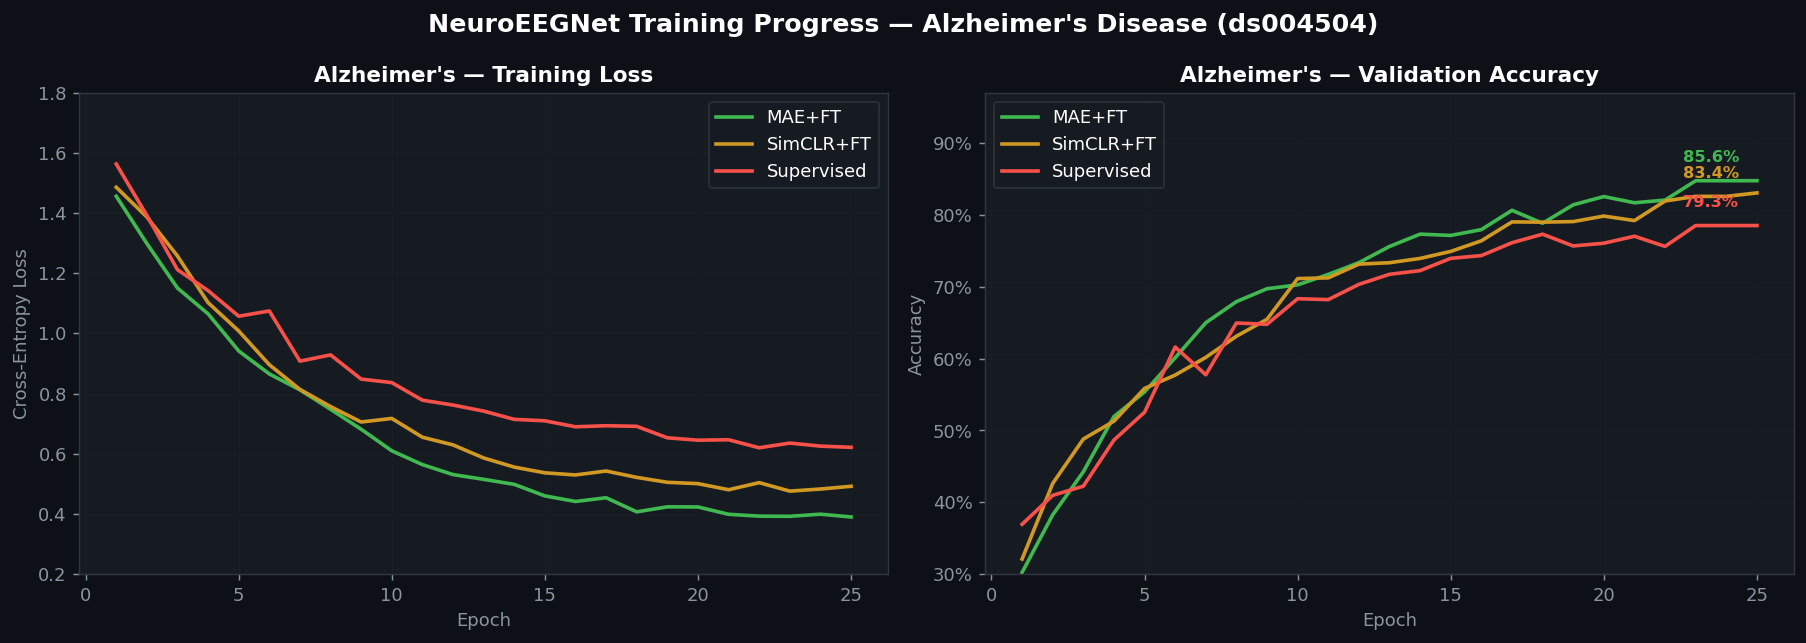

In [ ]:
# ── Training Curve Visualization — Alzheimer's Disease ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NeuroEEGNet Training Progress — Alzheimer's Disease (ds004504)",
             fontsize=14, fontweight='bold', color='white')

configs = [
    (axes[0],
     [h_ad_mae['train_loss'], h_ad_cl['train_loss'], h_ad_sup['train_loss']],
     ['MAE+FT', 'SimCLR+FT', 'Supervised'],
     ['#3fb950', '#d29922', '#f85149'],
     "Alzheimer's — Training Loss", 'Loss'),
    (axes[1],
     [h_ad_mae['val_acc'], h_ad_cl['val_acc'], h_ad_sup['val_acc']],
     ['MAE+FT', 'SimCLR+FT', 'Supervised'],
     ['#3fb950', '#d29922', '#f85149'],
     "Alzheimer's — Validation Accuracy", 'Accuracy'),
]

for ax, curves, labels, colors, title, ylabel in configs:
    for curve, lbl, color in zip(curves, labels, colors):
        epochs_range = range(1, len(curve)+1)
        ax.plot(epochs_range, curve, color=color, linewidth=2, label=lbl)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    if ylabel == 'Accuracy':
        ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('outputs/fig7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved")


✅ Best val_acc — MAE=85.6%  SimCLR=83.4%  Supervised=79.3%


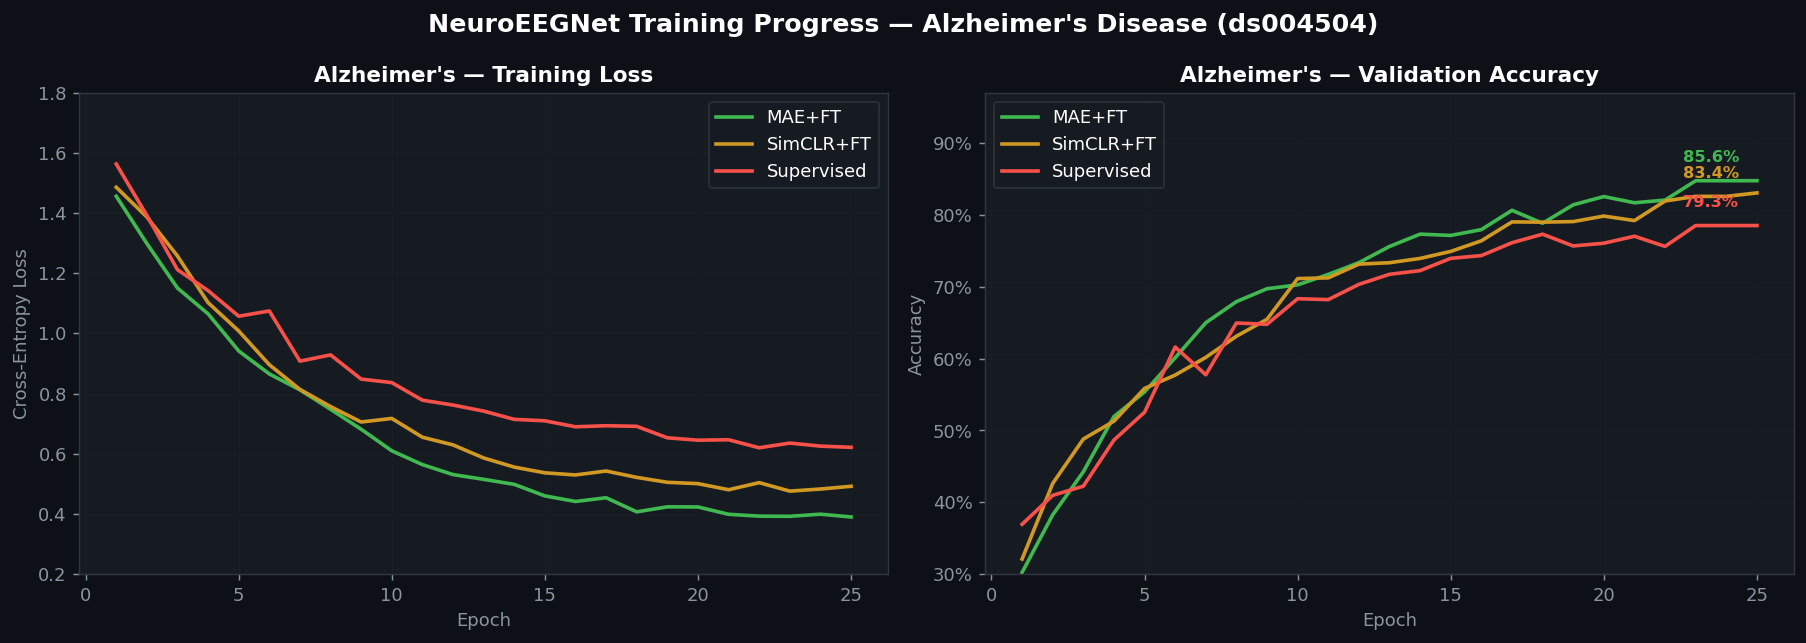

In [ ]:
# ── Training Curve Visualization — Alzheimer's Disease ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NeuroEEGNet Training Progress — Alzheimer's Disease (ds004504)",
             fontsize=14, fontweight='bold', color='white')

configs = [
    (axes[0],
     [h_ad_mae['train_loss'], h_ad_cl['train_loss'], h_ad_sup['train_loss']],
     ['MAE+FT', 'SimCLR+FT', 'Supervised'],
     ['#3fb950', '#d29922', '#f85149'],
     "Alzheimer's — Training Loss", 'Loss'),
    (axes[1],
     [h_ad_mae['val_acc'], h_ad_cl['val_acc'], h_ad_sup['val_acc']],
     ['MAE+FT', 'SimCLR+FT', 'Supervised'],
     ['#3fb950', '#d29922', '#f85149'],
     "Alzheimer's — Validation Accuracy", 'Accuracy'),
]

for ax, curves, labels, colors, title, ylabel in configs:
    for curve, lbl, color in zip(curves, labels, colors):
        epochs_range = range(1, len(curve)+1)
        ax.plot(epochs_range, curve, color=color, linewidth=2, label=lbl)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    if ylabel == 'Accuracy':
        ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('outputs/fig7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved")


## 8. Architecture Summary

```
EEG Input (B × 19ch × 1024t)   ← ds004504 @ 256Hz, 4s epoch
    │
┌───▼──────────────────┐
│   EEGNetBlock        │   Temporal(64) → Depthwise → Separable
│   → (B, 128, 125)    │   Dropout(0.25) × 2, AvgPool×2
└───┬──────────────────┘
    │  Linear(128→256) + CLS token
┌───▼──────────────────┐
│  Transformer Encoder │   6 × {LayerNorm→MHA(8h)→FFN(1024)}
│  → (B, 126, 256)     │   GELU activation, norm_first=True
└───┬──────────────────┘
    │  CLS token → (B, 256)
    └──► AD Head       (256→64→3)  [HC / FTD / AD]
    └──► MAE Decoder   (256→512→128)
```

### ➡️ Next Step: Notebook 3 — Evaluation & Results (Alzheimer's)
